# AI Foundations & Learning Models - Trabalho final - Análise de sentimento com DNN (Deep Neural Network)

Este notebook aplica uma DNN para classificar o sentimento de avaliações de clientes da **Quantum Commerce** em `Positivo`, `Negativo` ou `Neutro`, e compara essa escolha com outras abordagens vistas ao longo da disciplina.

Etapas do notebook:
1. Carregamento do dataset real **B2W-Reviews01** (avaliações reais de e-commerce em português)
2. Preparação dos dados: **Lematização com spaCy**, remoção de stopwords em português e vetorização **TF-IDF**
3. Baseline com **Regressão Logística**, validado com **Cross-Validation (k-fold)**
4. **Deep Neural Network** (3 camadas ocultas, ReLU, L2, Dropout) treinada com Backpropagation, SGD+Momentum e **Random Restart**
5. Avaliação com métricas de classificação (Accuracy, F1-macro, confusion matrix)
6. **Word2Vec** (gensim) como representação alternativa por embeddings, comparado com o TF-IDF
7. Demonstração conceitual do mecanismo de **Attention**
8. **BERT (BERTimbau)** via **Transfer Learning**: feature extraction (backbone congelado) e fine-tuning (opcional)
9. Comparativo geral de todas as abordagens testadas
10. Gráficos de análise do modelo escolhido para produção (model complexity graph e termômetro de satisfação)


## 0. Importação das dependências

In [13]:
import os
import sys

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # silence TensorFlow C++ init/GPU-support log noise
os.environ["HF_HUB_VERBOSITY"] = "error"  # silence HF Hub "unauthenticated requests" notice

import tensorflow as tf
tf.get_logger().setLevel("ERROR")  # silence tf.reset_default_graph deprecation-style log warnings

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

try:
    import spacy
except ImportError:
    get_ipython().system(f'{sys.executable} -m pip install -q spacy')
    import spacy

from spacy.lang.pt.stop_words import STOP_WORDS as STOPWORDS_PT_SET
STOPWORDS_PT = sorted(STOPWORDS_PT_SET)
print(f"Stopwords em português carregadas via spaCy: {len(STOPWORDS_PT)}")

try:
    nlp_lemma = spacy.load("pt_core_news_sm")
except OSError:
    get_ipython().system(f'{sys.executable} -m spacy download pt_core_news_sm')
    nlp_lemma = spacy.load("pt_core_news_sm")
print("Pipeline de lematização em português (spaCy pt_core_news_sm) carregado.")

# gensim: usado para treinar o Word2Vec
try:
    import gensim
    from gensim.models import Word2Vec
except ImportError:
    get_ipython().system(f'{sys.executable} -m pip install -q gensim')
    import gensim
    from gensim.models import Word2Vec

# torch + transformers: usados para BERT (transfer learning / finetuning)
try:
    import torch
    from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer
except ImportError:
    get_ipython().system(f'{sys.executable} -m pip install -q torch transformers')
    import torch
    from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer

print("Todas as dependências carregadas com sucesso.")


Stopwords em português carregadas via spaCy: 416
Pipeline de lematização em português (spaCy pt_core_news_sm) carregado.
Todas as dependências carregadas com sucesso.


## 1. Carregamento do dataset (B2W-Reviews01)

Usamos o **B2W-Reviews01**, corpus aberto com mais de 130 mil avaliações reais de e-commerce em
português, coletadas do site da Americanas.com. Fonte: https://github.com/americanas-tech/b2w-reviews01

O dataset traz `review_text` (texto da avaliação) e `overall_rating` (nota de 1 a 5 estrelas). Convertendo
a nota em 3 classes de sentimento:

- `overall_rating` 1–2 → **Negativo**
- `overall_rating` 3   → **Neutro**
- `overall_rating` 4–5 → **Positivo**

Fazemos uma amostragem **estratificada** por classe em vez de usar as ~130 mil linhas inteiras para
manter o treinamento rápido em ambiente de aula, e cacheamos o resultado em CSV local para não
precisar baixar o dataset a cada execução.

In [14]:
URL_B2W = "https://raw.githubusercontent.com/americanas-tech/b2w-reviews01/main/B2W-Reviews01.csv"
ARQUIVO_CACHE = "b2w_reviews_amostra.csv"
N_POR_CLASSE = 2000  # amostra estratificada: ~2000 reviews por classe (~6000 no total)
SEED = 42


def rating_para_sentimento(nota):
    if nota <= 2:
        return "Negativo"
    elif nota == 3:
        return "Neutro"
    else:
        return "Positivo"


def carregar_dataset_b2w(url=URL_B2W, n_por_classe=N_POR_CLASSE, seed=SEED):
    print("Baixando e amostrando o B2W-Reviews01 (avaliações reais de e-commerce em português)...")
    df_raw = pd.read_csv(url, sep=",", quotechar='"', encoding="utf-8")
    df_raw = df_raw[["review_text", "overall_rating"]].dropna()
    df_raw["review_text"] = df_raw["review_text"].astype(str).str.strip()
    df_raw = df_raw[df_raw["review_text"] != ""]

    df_raw["sentimento"] = df_raw["overall_rating"].apply(rating_para_sentimento)
    df_raw = df_raw.rename(columns={"review_text": "texto_review"})[["texto_review", "sentimento"]]

    # Amostragem estratificada: mesmo número de linhas por classe (quando disponível),
    # o que evita que o desbalanceamento natural de avaliações positivas no e-commerce
    # domine o treinamento.
    partes = []
    for classe, grupo in df_raw.groupby("sentimento"):
        n = min(len(grupo), n_por_classe)
        partes.append(grupo.sample(n=n, random_state=seed))
    df_amostra = pd.concat(partes).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df_amostra


if os.path.exists(ARQUIVO_CACHE):
    print(f"Carregando amostra já cacheada em '{ARQUIVO_CACHE}'...")
    df = pd.read_csv(ARQUIVO_CACHE)
else:
    df = carregar_dataset_b2w()
    df.to_csv(ARQUIVO_CACHE, index=False)


print(f"\nTotal de avaliações carregadas: {len(df)}")
print(df["sentimento"].value_counts())


Carregando amostra já cacheada em 'b2w_reviews_amostra.csv'...

Total de avaliações carregadas: 6000
sentimento
Negativo    2000
Neutro      2000
Positivo    2000
Name: count, dtype: int64


## 2. Pandas: Lematização e preparação dos Dados

### 2.1. Lematização com spaCy

Antes da vetorização, reduzimos cada palavra à sua forma-base (lema). O NLTK não tem suporte a lematização 
em português, então usamos o spaCy (`pt_core_news_sm`), como recomendado no material da disciplina. 
Desligamos os componentes `parser` e `ner` do pipeline (não precisamos deles aqui) para acelerar o 
processamento em lote via `nlp.pipe`.

Importante: mantemos as *stopwords* no texto lematizado (`texto_lematizado`). A remoção de stopwords
é feita depois, de forma diferente para cada representação: o `TfidfVectorizer` remove-as via o
parâmetro `stop_words`, enquanto o `Word2Vec` (Seção 6) as mantém, pois elas fornecem contexto útil
para o modelo aprender relações semânticas entre palavras.

In [15]:
def lematizar_corpus(textos, nlp=nlp_lemma, batch_size=64):
    saida = []
    for doc in nlp.pipe(textos, batch_size=batch_size, disable=["parser", "ner"]):
        tokens = [tok.lemma_.lower() for tok in doc if tok.is_alpha]
        saida.append(" ".join(tokens))
    return saida


print("Lematizando os textos com spaCy... isso pode levar alguns minutos.")
df["texto_lematizado"] = lematizar_corpus(df["texto_review"].tolist())

print("\nExemplo antes/depois da lematização:")
print("Original:   ", df["texto_review"].iloc[0])
print("Lematizado: ", df["texto_lematizado"].iloc[0])


Lematizando os textos com spaCy... isso pode levar alguns minutos.

Exemplo antes/depois da lematização:
Original:    A entrega da americanas foi num prazo menor do que a previsão do site, porém é o segundo produto que eu compra que vem somente com a  caixa do próprio produto e não vem com uma outra caixa de papelão mais  reforçada para protegê-lo. Como os demais comentários aqui, achei o cabo de energia e a mangueira de sucção muito curtas, se faz necessário a utilização de uma extensão, o manual tem 4 páginas e é horrível, demorei um tempão pra descobrir que o você deve ficar pressionando o botão de liga pó uns 10 segundos pra ele se manter ligado é que o outro botão que, aparentemente, seria de desliga e, parecia travado, não serve pra nada, coisa que no manual não fala. E ainda tem uma peça avulsa redonda com uns furos que eu ainda não consegui descobrir pra que serve.
Lematizado:  o entrega de o americana ser em um prazo pequeno de o que o previsão de o site porém ser o segundo pr

### 2.2. Vetorização TF-IDF

In [16]:
print("Vetorizando os textos lematizados...")
vectorizer = TfidfVectorizer(max_features=500, stop_words=STOPWORDS_PT, lowercase=True)
X = vectorizer.fit_transform(df["texto_lematizado"]).toarray()

# Transformando os rótulos de sentimento em categorias numéricas (One-Hot Encoding)
y_dummies = pd.get_dummies(df["sentimento"])
y = y_dummies.values
classes = y_dummies.columns.tolist()
rotulos = df["sentimento"].values

# Separação em treino e teste, com stratify para preservar a proporção das 3 classes
# (importante porque o dataset real é desbalanceado — avaliações positivas predominam)
X_train, X_test, y_train, y_test, rotulos_train, rotulos_test = train_test_split(
    X, y, rotulos, test_size=0.2, random_state=42, stratify=rotulos
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print(f"Vocabulário TF-IDF (após lematização e remoção de stopwords em PT): {len(vectorizer.vocabulary_)} termos")


Vetorizando os textos lematizados...
Treino: 4800 amostras | Teste: 1200 amostras
Vocabulário TF-IDF (após lematização e remoção de stopwords em PT): 500 termos


## 3. Baseline de comparação: Regressão Logística

Antes de justificar a Deep Neural Network, treinamos um modelo bem mais simples — **Regressão
Logística** multiclasse sobre os mesmos vetores TF-IDF — como baseline. Isso torna concreta a
comparação feita na justificativa da arquitetura (Seção 2 do trabalho escrito): mostramos, com
números, o quanto (ou quão pouco) a DNN melhora sobre uma alternativa simples e barata.

In [17]:
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train, rotulos_train)

pred_baseline = baseline.predict(X_test)

acc_baseline = accuracy_score(rotulos_test, pred_baseline)
f1_baseline = f1_score(rotulos_test, pred_baseline, average="macro", zero_division=0)

print("=== Baseline: Regressão Logística (hold-out) ===")
print(f"Acurácia: {acc_baseline:.4f}")
print(f"F1-macro: {f1_baseline:.4f}")
print(classification_report(rotulos_test, pred_baseline, zero_division=0))


=== Baseline: Regressão Logística (hold-out) ===
Acurácia: 0.6575
F1-macro: 0.6534
              precision    recall  f1-score   support

    Negativo       0.70      0.78      0.74       400
      Neutro       0.55      0.49      0.52       400
    Positivo       0.71      0.70      0.70       400

    accuracy                           0.66      1200
   macro avg       0.65      0.66      0.65      1200
weighted avg       0.65      0.66      0.65      1200



### 3.1. Validação cruzada (Cross-Validation)

Um único split treino/teste pode ser otimista ou pessimista por acaso da divisão. Aplicamos 
**Cross-Validation k-fold (k=5)** no baseline para obter uma estimativa mais robusta de desempenho 
(média ± desvio-padrão entre 5 divisões diferentes dos dados).

Não aplicamos k-fold completo na DNN da Seção 4: como ela já treina 5 vezes por causa do Random
Restart, um 5-fold multiplicaria isso por mais 5× (25 treinamentos de rede neural). Para a DNN, 
seguimos a prática padrão em Deep Learning — um conjunto de validação (hold-out) monitorado via Early
Stopping (Seção 5) — que cumpre um papel semelhante ao da validação cruzada a um custo computacional muito menor.

In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_resultados = cross_validate(
    LogisticRegression(max_iter=1000, random_state=42),
    X, rotulos, cv=skf, scoring=["accuracy", "f1_macro"]
)

print("=== Regressão Logística: Cross-Validation (5-fold) ===")
print(f"Acurácia média: {cv_resultados['test_accuracy'].mean():.4f} (+/- {cv_resultados['test_accuracy'].std():.4f})")
print(f"F1-macro médio: {cv_resultados['test_f1_macro'].mean():.4f} (+/- {cv_resultados['test_f1_macro'].std():.4f})")


=== Regressão Logística: Cross-Validation (5-fold) ===
Acurácia média: 0.6522 (+/- 0.0158)
F1-macro médio: 0.6513 (+/- 0.0150)


## 4. DNN: Arquitetura proposta

Arquitetura com **3 camadas ocultas** (128 → 64 → 32 neurônios), ativação **ReLU**, **Regularização L2** e **Dropout** em todas elas, encerrando em uma camada de saída **Softmax** (probabilidades por classe de sentimento). A função `construir_modelo` recebe uma `seed` de inicialização de pesos, o que será usado na próxima etapa para aplicar a técnica de **Random Restart**.

In [19]:
def construir_modelo(input_dim, output_dim, seed):
    inicializador = tf.keras.initializers.GlorotUniform(seed=seed)

    model = Sequential([
        Input(shape=(input_dim,)),

        # Camada oculta 1 com ativação ReLU (evita Vanishing Gradient) e regularização L2
        Dense(128, activation='relu', kernel_regularizer=l2(0.001),
              kernel_initializer=inicializador),
        Dropout(0.3),

        # Camada oculta 2
        Dense(64, activation='relu', kernel_regularizer=l2(0.001),
              kernel_initializer=inicializador),
        Dropout(0.3),

        # Camada oculta 3 (múltiplas camadas ocultas -> aprendizado profundo)
        Dense(32, activation='relu', kernel_regularizer=l2(0.001),
              kernel_initializer=inicializador),
        Dropout(0.3),

        # Camada de saída com Softmax para obter probabilidades de classificação multi-classe
        Dense(output_dim, activation='softmax', kernel_initializer=inicializador)
    ])

    # Otimizador SGD com Momentum (ajuda a escapar de mínimos locais e chegar ao mínimo global)
    sgd = SGD(learning_rate=0.01, momentum=0.9)

    # Compilando com a error function Log Loss (categorical_crossentropy)
    model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])

    return model


print("Construindo a DNN...")
model_referencia = construir_modelo(X.shape[1], y.shape[1], seed=42)
model_referencia.summary()


Construindo a DNN...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,563 (291.26 KB)

 Trainable params: 74,563 (291.26 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Treinamento (Backpropagation + SGD/Momentum + Random Restart)

Conforme descrito na fuga de mínimos locais, além do **Momentum**, aplicamos a técnica de **Random Restart**: o modelo é treinado várias vezes a partir de pontos de inicialização aleatórios distintos (sementes diferentes), e mantemos apenas a execução que atingiu o menor erro de teste (`val_loss`), evitando ficar preso em um mínimo local subótimo de uma única inicialização.

In [20]:
print("Iniciando o treinamento com Random Restart...\n")

sementes_random_restart = [7, 21, 42, 99, 123]

melhor_val_loss = np.inf
melhor_modelo = None
melhor_historico = None
melhor_semente = None
melhor_early_stop = None

for semente in sementes_random_restart:
    print(f"--- Random Restart | Inicialização com seed={semente} ---")

    # Reinicia o estado do Keras/TF para garantir que cada tentativa parta do zero
    tf.keras.backend.clear_session()
    tf.random.set_seed(semente)
    np.random.seed(semente)

    modelo_tentativa = construir_modelo(X.shape[1], y.shape[1], seed=semente)

    # Early Stopping para interromper na época ideal (Just Right) observando o erro de teste
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    historico_tentativa = modelo_tentativa.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    val_loss_tentativa = min(historico_tentativa.history['val_loss'])
    print(f"    -> Val Loss (Log Loss no teste): {val_loss_tentativa:.4f}\n")

    # Mantemos apenas a melhor tentativa (menor erro de teste) entre todos os restarts
    if val_loss_tentativa < melhor_val_loss:
        melhor_val_loss = val_loss_tentativa
        melhor_modelo = modelo_tentativa
        melhor_historico = historico_tentativa
        melhor_semente = semente
        melhor_early_stop = early_stop

model = melhor_modelo
history = melhor_historico
early_stop = melhor_early_stop

print("Treinamento concluído.")
print(f"Melhor execução (Random Restart): seed={melhor_semente} | Val Loss = {melhor_val_loss:.4f}")
model.summary()


Iniciando o treinamento com Random Restart...

--- Random Restart | Inicialização com seed=7 ---
    -> Val Loss (Log Loss no teste): 0.9520

--- Random Restart | Inicialização com seed=21 ---
    -> Val Loss (Log Loss no teste): 0.9276

--- Random Restart | Inicialização com seed=42 ---
    -> Val Loss (Log Loss no teste): 0.9261

--- Random Restart | Inicialização com seed=99 ---
    -> Val Loss (Log Loss no teste): 0.9230

--- Random Restart | Inicialização com seed=123 ---
    -> Val Loss (Log Loss no teste): 0.9330

Treinamento concluído.
Melhor execução (Random Restart): seed=99 | Val Loss = 0.9230


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,128 (582.54 KB)

 Trainable params: 74,563 (291.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 74,565 (291.27 KB)

## 6. Avaliação: métricas de classificação (Baseline x DNN)

Além do Log Loss acompanhado durante o treinamento, avaliamos o modelo final no conjunto de teste
com métricas de classificação padrão — **Accuracy**, **F1-macro** (mais robusto que a acurácia sob
desbalanceamento de classes) e a **confusion matrix** — e comparamos diretamente com o baseline de
regressão logística treinado na Seção 3.

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
=== DNN (melhor execução do Random Restart) ===
Accuracy: 0.6508
F1-macro: 0.6429
              precision    recall  f1-score   support

    Negativo       0.69      0.81      0.74       400
      Neutro       0.53      0.43      0.48       400
    Positivo       0.70      0.71      0.71       400

    accuracy                           0.65      1200
   macro avg       0.64      0.65      0.64      1200
weighted avg       0.64      0.65      0.64      1200

=== Comparativo Baseline x DNN ===
                        Modelo  Accuracy  F1-macro
Regressão logística (baseline)  0.657500  0.653427
                           DNN  0.650833  0.642862


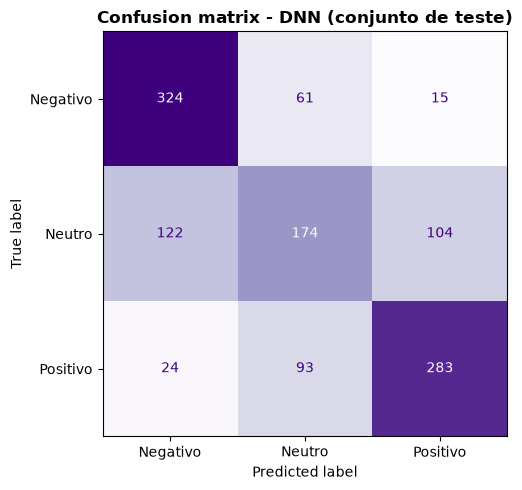

In [21]:
probs_teste = model.predict(X_test)
pred_dnn = [classes[i] for i in np.argmax(probs_teste, axis=1)]

acc_dnn = accuracy_score(rotulos_test, pred_dnn)
f1_dnn = f1_score(rotulos_test, pred_dnn, average="macro", zero_division=0)

print("=== DNN (melhor execução do Random Restart) ===")
print(f"Accuracy: {acc_dnn:.4f}")
print(f"F1-macro: {f1_dnn:.4f}")
print(classification_report(rotulos_test, pred_dnn, zero_division=0))

print("=== Comparativo Baseline x DNN ===")
comparativo = pd.DataFrame({
    "Modelo": ["Regressão logística (baseline)", "DNN"],
    "Accuracy": [acc_baseline, acc_dnn],
    "F1-macro": [f1_baseline, f1_dnn],
})
print(comparativo.to_string(index=False))

# Confusion matrix da DNN
fig, ax = plt.subplots(figsize=(6, 5))
matriz = confusion_matrix(rotulos_test, pred_dnn, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=classes)
disp.plot(ax=ax, cmap="Purples", colorbar=False)
plt.title("Confusion matrix - DNN (conjunto de teste)", fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Word2Vec: representação alternativa via Embeddings

O TF-IDF (Seção 2) representa cada review como uma contagem ponderada de palavras — é um modelo de
*bag of words*, que ignora a ordem e o significado das palavras (duas frases com as mesmas palavras em
ordens diferentes geram o mesmo vetor). O **Word2Vec** (visto na disciplina) resolve parte desse
problema: ao treinar uma rede rasa para prever palavras a partir do seu contexto (Skip-gram), ele
aprende **embeddings** — vetores densos em que palavras com significados semelhantes ficam próximas
no espaço vetorial.

Aqui treinamos um Word2Vec no próprio corpus de reviews (abordagem Skip-gram, `sg=1`) e representamos
cada review pela **média dos vetores das suas palavras**, exatamente como no notebook de referência da
disciplina. Como o corpus (~6 mil reviews) é pequeno para o padrão de Word2Vec — modelos desse tipo
costumam se beneficiar de milhões de palavras — os embeddings aprendidos aqui são apenas ilustrativos;
em produção, o ideal seria usar embeddings pré-treinados em um corpus grande de português (ex.: NILC
embeddings) ou partir direto para um modelo pré-treinado como o BERT (Seção 8).

In [22]:
textos_tokenizados = [texto.split() for texto in df["texto_lematizado"]]

w2v_model = Word2Vec(
    sentences=textos_tokenizados,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,  # Skip-gram (sg=0 seria CBOW)
    workers=os.cpu_count() or 1,
    seed=42,
)
print(f"Vocabulário aprendido pelo Word2Vec: {len(w2v_model.wv)} palavras")

# Exemplo de relação semântica aprendida (pode variar dependendo da amostra sorteada)
if "produto" in w2v_model.wv:
    print("Palavras mais similares a 'produto':", w2v_model.wv.most_similar("produto", topn=5))


def vetor_medio(tokens, modelo, dim):
    vetores = [modelo.wv[t] for t in tokens if t in modelo.wv]
    if len(vetores) == 0:
        return np.zeros(dim)
    return np.mean(vetores, axis=0)


X_w2v = np.array([vetor_medio(tokens, w2v_model, 100) for tokens in textos_tokenizados])

X_w2v_train, X_w2v_test, rot_w2v_train, rot_w2v_test = train_test_split(
    X_w2v, rotulos, test_size=0.2, random_state=42, stratify=rotulos
)

clf_w2v = LogisticRegression(max_iter=1000, random_state=42)
clf_w2v.fit(X_w2v_train, rot_w2v_train)
pred_w2v = clf_w2v.predict(X_w2v_test)

acc_w2v = accuracy_score(rot_w2v_test, pred_w2v)
f1_w2v = f1_score(rot_w2v_test, pred_w2v, average="macro", zero_division=0)

print(f"\n=== Word2Vec (médio) + Regressão Logística ===")
print(f"Acurácia: {acc_w2v:.4f}")
print(f"F1-macro: {f1_w2v:.4f}")


Vocabulário aprendido pelo Word2Vec: 4135 palavras
Palavras mais similares a 'produto': [('certeza', 0.7929953932762146), ('exatamente', 0.7852699756622314), ('livro', 0.7804440259933472), ('mercadoria', 0.7747613787651062), ('especificação', 0.7734246850013733)]

=== Word2Vec (médio) + Regressão Logística ===
Acurácia: 0.6625
F1-macro: 0.6592


## 8. Attention: Demonstração conceitual

O Word2Vec e o TF-IDF representam cada palavra (ou o documento inteiro) de forma "estática" — o vetor
da palavra "banco" é o mesmo numa frase sobre finanças ou sobre um banco de praça. O mecanismo de
**Attention**, base dos Transformers e do BERT (Seção 9), resolve isso: cada palavra passa a "olhar"
para as outras palavras da frase e pondera o quanto cada uma delas é relevante para entender o seu
próprio significado no contexto.

Abaixo, uma implementação simplificada do **Scaled Dot-Product Attention** (a fórmula central do
Transformer) sobre um exemplo de brinquedo, só para ilustrar o mecanismo — não é o Attention
"aprendido" de um modelo treinado, mas mostra a mecânica: cada célula do mapa de calor representa o
quanto uma palavra (linha) "presta atenção" em outra palavra (coluna) da mesma frase.

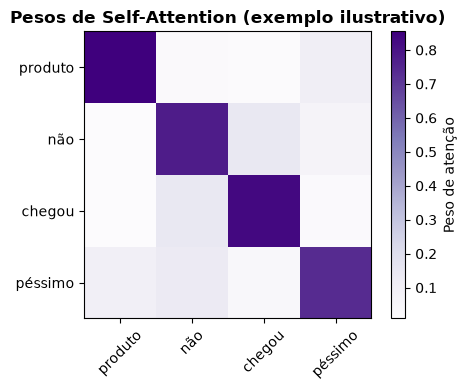

Em cada linha, os pesos somam 1 (saída do softmax) e indicam o quanto aquele token
'atende' a cada um dos outros tokens da frase, incluindo ele mesmo:
[[0.855 0.023 0.019 0.103]
 [0.011 0.776 0.144 0.068]
 [0.009 0.142 0.829 0.02 ]
 [0.095 0.129 0.038 0.738]]


In [23]:
def softmax(x, axis=-1):
    e = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e / np.sum(e, axis=axis, keepdims=True)


def scaled_dot_product_attention(Q, K, V):
    """Fórmula central do Transformer: Attention(Q, K, V) = softmax(Q Kᵀ / sqrt(d_k)) V"""
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    pesos = softmax(scores)
    saida = pesos @ V
    return saida, pesos


# Frase de exemplo (um review negativo curto), com embeddings aleatórios apenas ilustrativos
np.random.seed(42)
tokens_exemplo = ["produto", "não", "chegou", "péssimo"]
dim_embedding = 8
Q = K = V = np.random.randn(len(tokens_exemplo), dim_embedding)

saida_attention, pesos_attention = scaled_dot_product_attention(Q, K, V)

plt.figure(figsize=(5, 4))
plt.imshow(pesos_attention, cmap="Purples")
plt.xticks(range(len(tokens_exemplo)), tokens_exemplo, rotation=45)
plt.yticks(range(len(tokens_exemplo)), tokens_exemplo)
plt.title("Pesos de Self-Attention (exemplo ilustrativo)", fontweight="bold")
plt.colorbar(label="Peso de atenção")
plt.tight_layout()
plt.show()

print("Em cada linha, os pesos somam 1 (saída do softmax) e indicam o quanto aquele token")
print("'atende' a cada um dos outros tokens da frase, incluindo ele mesmo:")
print(np.round(pesos_attention, 3))


## 9. BERT (BERTimbau): Transfer Learning via Feature Extraction

Chegamos à técnica mais avançada para NLP: usar um modelo de linguagem
**pré-treinado** — o BERT — via **Transfer Learning**. Em vez de aprender uma representação de texto do
zero (como fizemos com TF-IDF e Word2Vec, usando só os nossos ~6 mil reviews), aproveitamos um modelo
que já "leu" uma quantidade enorme de texto em português.

Usamos o **BERTimbau** (`neuralmind/bert-base-portuguese-cased`), um BERT pré-treinado especificamente
em português. A estratégia aqui é a de **Feature Extraction** (backbone 100% congelado, como visto na
Aula de Fine-Tuning): passamos os reviews pelo BERT sem treinar nenhum peso dele (só *forward pass*,
sem backpropagation), extraímos o embedding do token especial `[CLS]` — que o BERT usa para resumir a
frase inteira — e treinamos apenas um classificador leve (Regressão Logística) em cima desses
embeddings. É rápida, funciona em CPU e não corre risco de *catastrophic forgetting* (não alteramos os
pesos do BERT).

Por custo computacional, extraímos embeddings de uma amostra menor do dataset (a extração é só
inferência, mas ainda assim mais pesada que TF-IDF/Word2Vec).

In [24]:
MODELO_BERT = "neuralmind/bert-base-portuguese-cased"  # BERTimbau
N_AMOSTRA_BERT = 1200

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo utilizado: {device}")

tokenizer_bert = AutoTokenizer.from_pretrained(MODELO_BERT)
modelo_bert = AutoModel.from_pretrained(MODELO_BERT)
modelo_bert.to(device)
modelo_bert.eval()  # backbone congelado: só inferência, sem treinar pesos


def extrair_embeddings_bert(textos, tokenizer, modelo, device, batch_size=16, max_length=128):
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(textos), batch_size):
            lote = textos[i:i + batch_size]
            entradas = tokenizer(
                lote, padding=True, truncation=True, max_length=max_length, return_tensors="pt"
            ).to(device)
            saida = modelo(**entradas)
            # embedding do token [CLS] (primeira posição) como representação da frase inteira
            embedding_cls = saida.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(embedding_cls)
    return np.vstack(embeddings)


df_bert = df.sample(n=min(N_AMOSTRA_BERT, len(df)), random_state=42).reset_index(drop=True)

print(f"Extraindo embeddings do BERTimbau (feature extraction) para {len(df_bert)} reviews...")
X_bert = extrair_embeddings_bert(df_bert["texto_review"].tolist(), tokenizer_bert, modelo_bert, device)

X_bert_train, X_bert_test, rot_bert_train, rot_bert_test = train_test_split(
    X_bert, df_bert["sentimento"].values, test_size=0.2, random_state=42,
    stratify=df_bert["sentimento"].values
)

clf_bert = LogisticRegression(max_iter=1000, random_state=42)
clf_bert.fit(X_bert_train, rot_bert_train)
pred_bert = clf_bert.predict(X_bert_test)

acc_bert = accuracy_score(rot_bert_test, pred_bert)
f1_bert = f1_score(rot_bert_test, pred_bert, average="macro", zero_division=0)

print(f"\n=== BERTimbau (Feature Extraction) + Regressão Logística ===")
print(f"Acurácia: {acc_bert:.4f}")
print(f"F1-macro: {f1_bert:.4f}")


Dispositivo utilizado: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extraindo embeddings do BERTimbau (feature extraction) para 1200 reviews...

=== BERTimbau (Feature Extraction) + Regressão Logística ===
Acurácia: 0.6750
F1-macro: 0.6669


## 10. BERT (BERTimbau): Fine-Tuning (opcional, requer GPU)

A segunda estratégia de Transfer Learning vista na disciplina é o **Fine-Tuning**: em vez de manter o
BERT totalmente congelado, "descongelamos" as últimas camadas e continuamos o treinamento delas (com
uma *learning rate* bem baixa, para não sofrer *catastrophic forgetting* — apagar o conhecimento
pré-treinado). Isso costuma superar a Feature Extraction, ao custo de mais tempo de treino e mais
memória.

**Esta célula é opcional e mais pesada.** Ela funciona em CPU, mas é bem mais rápida com GPU
(no Colab: *Ambiente de execução > Alterar o tipo de ambiente de execução > GPU*). Usamos uma amostra
ainda menor de reviews e só 2 épocas, apenas para demonstrar o pipeline de fine-tuning — em um cenário
real de produção, o ideal seria mais dados, mais épocas e acompanhamento via Early Stopping, como
fizemos com a DNN da Seção 5. Se esta célula falhar ou demorar demais no seu ambiente, pule para a
Seção 11 — as demais análises não dependem dela.

In [25]:
from torch.utils.data import Dataset

N_AMOSTRA_FINETUNE = 600  # amostra pequena, só para demonstrar o pipeline de fine-tuning


class ReviewsDataset(Dataset):
    def __init__(self, textos, rotulos_int, tokenizer, max_length=128):
        self.encodings = tokenizer(
            list(textos), padding=True, truncation=True, max_length=max_length
        )
        self.labels = list(rotulos_int)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {chave: torch.tensor(valor[idx]) for chave, valor in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


def calcular_metricas(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
    }


df_ft = df.sample(n=min(N_AMOSTRA_FINETUNE, len(df)), random_state=42).reset_index(drop=True)

codificador_rotulos = LabelEncoder()
rotulos_int = codificador_rotulos.fit_transform(df_ft["sentimento"])

textos_treino, textos_val, y_treino, y_val = train_test_split(
    df_ft["texto_review"].tolist(), rotulos_int, test_size=0.2, random_state=42, stratify=rotulos_int
)

tokenizer_ft = AutoTokenizer.from_pretrained(MODELO_BERT)
dataset_treino = ReviewsDataset(textos_treino, y_treino, tokenizer_ft)
dataset_val = ReviewsDataset(textos_val, y_val, tokenizer_ft)

modelo_finetune = AutoModelForSequenceClassification.from_pretrained(
    MODELO_BERT, num_labels=len(codificador_rotulos.classes_)
)

# Fine-Tuning Parcial (Aula 8): congelamos os embeddings e as camadas iniciais do
# backbone, e liberamos só as duas últimas camadas do encoder + o head de classificação.
for parametro in modelo_finetune.bert.embeddings.parameters():
    parametro.requires_grad = False
for camada in modelo_finetune.bert.encoder.layer[:-2]:
    for parametro in camada.parameters():
        parametro.requires_grad = False

argumentos_comuns = dict(
    output_dir="./bert_finetune_output",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,  # LR baixa para não apagar o conhecimento pré-treinado (catastrophic forgetting)
    logging_steps=20,
    save_strategy="no",
    report_to=[],
    seed=42,
    dataloader_pin_memory=False,  # sem GPU/accelerator disponível: pin_memory não teria efeito
)
try:
    # transformers >= 4.46 renomeou o parâmetro para eval_strategy
    argumentos_treino = TrainingArguments(eval_strategy="epoch", **argumentos_comuns)
except TypeError:
    argumentos_treino = TrainingArguments(evaluation_strategy="epoch", **argumentos_comuns)

trainer = Trainer(
    model=modelo_finetune,
    args=argumentos_treino,
    train_dataset=dataset_treino,
    eval_dataset=dataset_val,
    compute_metrics=calcular_metricas,
)

trainer.train()
resultado_finetune = trainer.evaluate()

acc_bert_ft = resultado_finetune["eval_accuracy"]
f1_bert_ft = resultado_finetune["eval_f1_macro"]
print(f"\n=== BERTimbau (Fine-Tuning) ===")
print(f"Acurácia: {acc_bert_ft:.4f}")
print(f"F1-macro: {f1_bert_ft:.4f}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.995783,0.925209,0.608333,0.584938
2,0.884836,0.859738,0.641667,0.611171


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.884836,0.859738,2,0.641667,0.611171



=== BERTimbau (Fine-Tuning) ===
Acurácia: 0.6417
F1-macro: 0.6112


## 11. Comparativo geral de todas as abordagens

Consolidamos os resultados de todas as abordagens testadas — da mais simples (Regressão Logística
sobre TF-IDF) até a mais sofisticada (BERT com Fine-Tuning) — no mesmo conjunto de métricas. A seção
"BERTimbau (Fine-Tuning)" só aparece se a Seção 10 (opcional) tiver sido executada.

                        Modelo  Acurácia  F1-macro
BERTimbau (Feature Extraction)  0.675000  0.666927
Word2Vec + Regressão Logística  0.662500  0.659206
  Regressão Logística (TF-IDF)  0.657500  0.653427
  Deep Neural Network (TF-IDF)  0.650833  0.642862
       BERTimbau (Fine-Tuning)  0.641667  0.611171


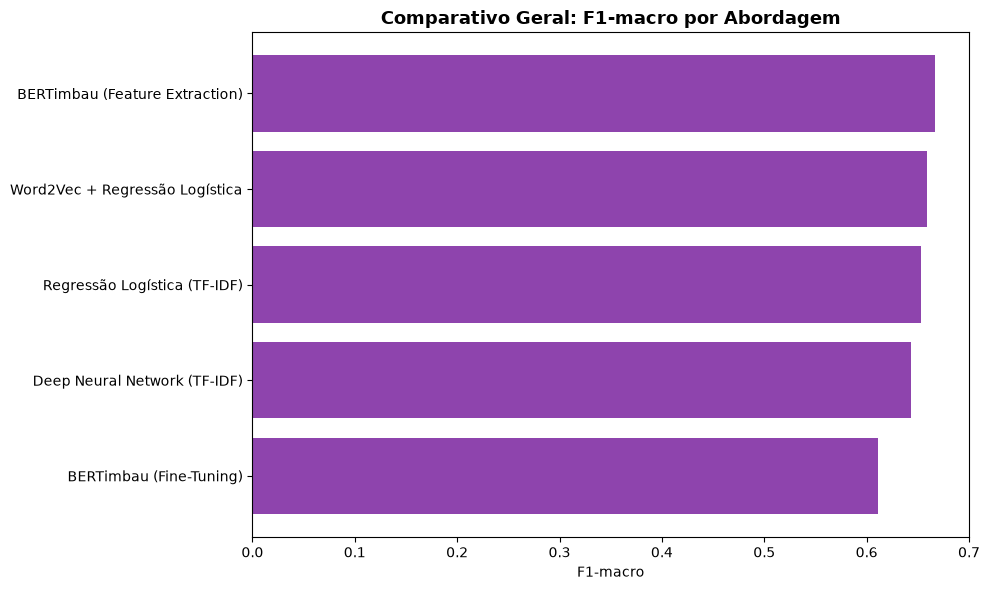


Nota: resultados obtidos em amostras menores (Word2Vec e, principalmente, BERT) tendem a ter
mais variância. Em produção, o ideal é reavaliar todas as abordagens sobre o mesmo conjunto de teste.


In [26]:
resultados = {
    "Regressão Logística (TF-IDF)": (acc_baseline, f1_baseline),
    "Deep Neural Network (TF-IDF)": (acc_dnn, f1_dnn),
    "Word2Vec + Regressão Logística": (acc_w2v, f1_w2v),
    "BERTimbau (Feature Extraction)": (acc_bert, f1_bert),
}
if "acc_bert_ft" in globals():
    resultados["BERTimbau (Fine-Tuning)"] = (acc_bert_ft, f1_bert_ft)

comparativo_geral = pd.DataFrame(
    [(nome, acc, f1) for nome, (acc, f1) in resultados.items()],
    columns=["Modelo", "Acurácia", "F1-macro"],
).sort_values("F1-macro", ascending=False).reset_index(drop=True)

print(comparativo_geral.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(comparativo_geral["Modelo"], comparativo_geral["F1-macro"], color="#8e44ad")
plt.xlabel("F1-macro")
plt.title("Comparativo Geral: F1-macro por Abordagem", fontsize=13, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nNota: resultados obtidos em amostras menores (Word2Vec e, principalmente, BERT) tendem a ter")
print("mais variância. Em produção, o ideal é reavaliar todas as abordagens sobre o mesmo conjunto de teste.")


## 12. Matplotlib: gráficos de análise do modelo escolhido (DNN)

A DNN treinada na Seção 5 continua sendo a arquitetura **escolhida para produção**, conforme
justificado no trabalho escrito (equilíbrio entre custo computacional e ganho de desempenho sobre os
baselines, com evolução natural para BERT/Transfer Learning à medida que o volume de dados e a
criticidade da aplicação justifiquem o custo — como demonstramos nas Seções 9 e 10). As visualizações
abaixo aplicam esse modelo ao cenário de negócio da Quantum Commerce.

### Gráfico 1: Model Complexity Graph (curva de erro de treinamento vs teste)

Refere-se à melhor execução obtida pelo **Random Restart** (seed selecionada na Seção 5).

Gerando gráficos de análise com Matplotlib...


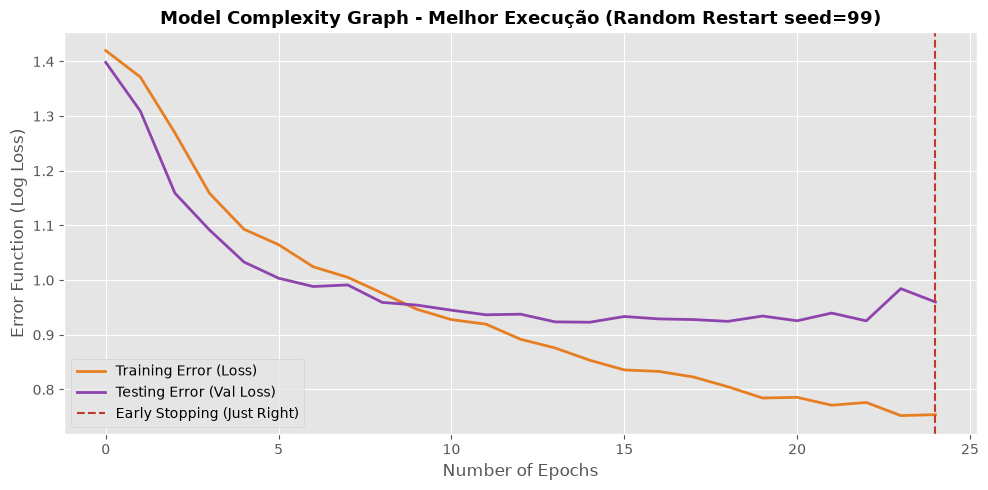

In [27]:
print("Gerando gráficos de análise com Matplotlib...")
plt.style.use('ggplot')

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Error (Loss)', color='#e67e22', linewidth=2)
plt.plot(history.history['val_loss'], label='Testing Error (Val Loss)', color='#8e44ad', linewidth=2)

plt.title(f'Model Complexity Graph - Melhor Execução (Random Restart seed={melhor_semente})', fontsize=13, fontweight='bold')
plt.xlabel('Number of Epochs')
plt.ylabel('Error Function (Log Loss)')

# Marcando a linha de Early Stopping
epoca_parada = early_stop.stopped_epoch if early_stop.stopped_epoch > 0 else len(history.history['loss']) - 1
plt.axvline(x=epoca_parada, color='#c0392b', linestyle='--', label='Early Stopping (Just Right)')

plt.legend()
plt.tight_layout()
plt.show()


### Gráfico 2: Termômetro de satisfação (análise aplicada ao catálogo)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step


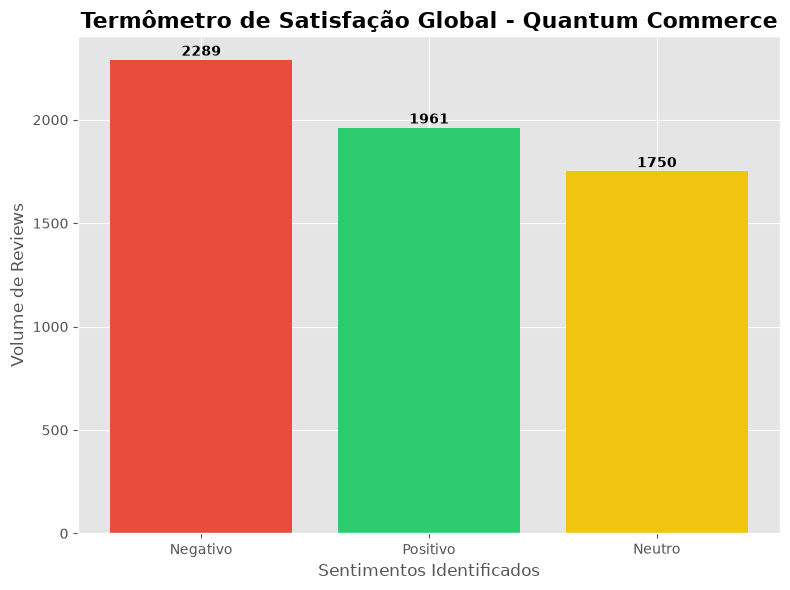


Processo finalizado com sucesso!


In [28]:
# Realiza a predição para todos os itens do dataset
predicoes = model.predict(X)
classes_preditas = [classes[np.argmax(pred)] for pred in predicoes]
df['predicao_sentimento'] = classes_preditas

contagem = df['predicao_sentimento'].value_counts()
cores_termometro = ['#2ecc71' if c == 'Positivo' else '#e74c3c' if c == 'Negativo' else '#f1c40f' for c in contagem.index]

plt.figure(figsize=(8, 6))
barras = plt.bar(contagem.index, contagem.values, color=cores_termometro)
plt.title('Termômetro de Satisfação Global - Quantum Commerce', fontsize=16, fontweight='bold')
plt.xlabel('Sentimentos Identificados', fontsize=12)
plt.ylabel('Volume de Reviews', fontsize=12)

# Adicionando rótulos de dados em cima de cada barra
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 5, f'{yval}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nProcesso finalizado com sucesso!")
